In [1]:
#Importing Dependencies
import pandas as pd
import cellrank as cr
import numpy as np
import scanpy as sc
import scvelo as scv
import palantir
from cellrank.kernels import PseudotimeKernel
from cellrank.kernels import CytoTRACEKernel
import scipy.stats as st

# Plotting
import matplotlib
import matplotlib.pyplot as plt

# warnings
import warnings
from numba.core.errors import NumbaDeprecationWarning

warnings.simplefilter("ignore", category=UserWarning)
warnings.filterwarnings(action="ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings(
    action="ignore", module="scanpy", message="No data for colormapping"
)


In [2]:
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor = 'white', dpi_save = 600, format ="png", transparent = False)
scv.settings.set_figure_params(dpi=80, facecolor = 'white', dpi_save = 600, format ="png", transparent = False,style = 'scvelo')
scv.settings.figdir = '/path/to/folder/'

2025-07-02 09:52:22.838937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-02 09:52:22.855596: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-02 09:52:22.860850: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-02 09:52:24.053946: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


scanpy==1.9.8 anndata==0.10.8 umap==0.5.4 numpy==1.26.4 scipy==1.11.4 pandas==2.0.3 scikit-learn==1.1.3 statsmodels==0.14.4 igraph==0.10.8 pynndescent==0.5.10


In [3]:
def split_umap(adata, split_by, ncol=2, nrow=None, save=False, **kwargs):
    categories = adata.obs[split_by].cat.categories
    if nrow is None:
        nrow = int(np.ceil(len(categories) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(5*ncol, 4*nrow))
    axs = axs.flatten()
    for i, cat in enumerate(categories):
        ax = axs[i]
        sc.pl.umap(adata[adata.obs[split_by] == cat], ax=ax, show=False, title=cat, **kwargs)
        ax.set_ylim(-10,10) #Remove to see the 2D section
        ax.set_xlim(2,12) #Remove to  see the 2D section
    plt.tight_layout()
    if save:
        fig.savefig('split_umap.png',transparent=None, dpi=600)

In [5]:
#Loading File with MAGIC Imputation
adata =  sc.read_h5ad('/nfs/turbo/umms-cparkos/globus/Ismael/Seurat_full_magic.h5ad') 

In [6]:
new_names = ['Transitional_2D',"Late_G1_3D", "Differentiated_2D", "Early_G1_3D",
             "Intermediate_2D", "BMI+Stem_2D", "LGR5+Stem_3D", "Undifferentiated_2D", "M-like_2D",
             "UC-specific_3D", "Hes+Stem_2D"]
adata.rename_categories('cell_anno', new_names)

In [7]:
adata.obs['orig.ident']
new_names = ['Healthy (1) 2D', 'Healthy (1) 3D', 
             'Healthy (2) 2D', 'Healthy (2) 3D',
             'Active UC 2D', 'Active UC 3D', 
             'Inactive UC 2D', 'Inactive UC 3D']

adata.obs['new.orig.ident']= adata.obs['orig.ident']
original_ident = adata.obs['orig.ident']

sample = [x.split("_")[0] for x in original_ident]

adata.obs['sample.condition'] = sample
adata.obs['sample.condition'] = adata.obs['sample.condition'].astype('category')

adata.rename_categories('new.orig.ident', new_names)

In [8]:
adata_3d = adata[adata.obs['orig.ident'].isin(["Healthy1_3D","Healthy2_3D","UC1_3D","UC2_3D"])]
adata_2d = adata[adata.obs['orig.ident'].isin(["Healthy1_2D","Healthy2_2D","UC1_2D","UC2_2D"])]

# Figure 4

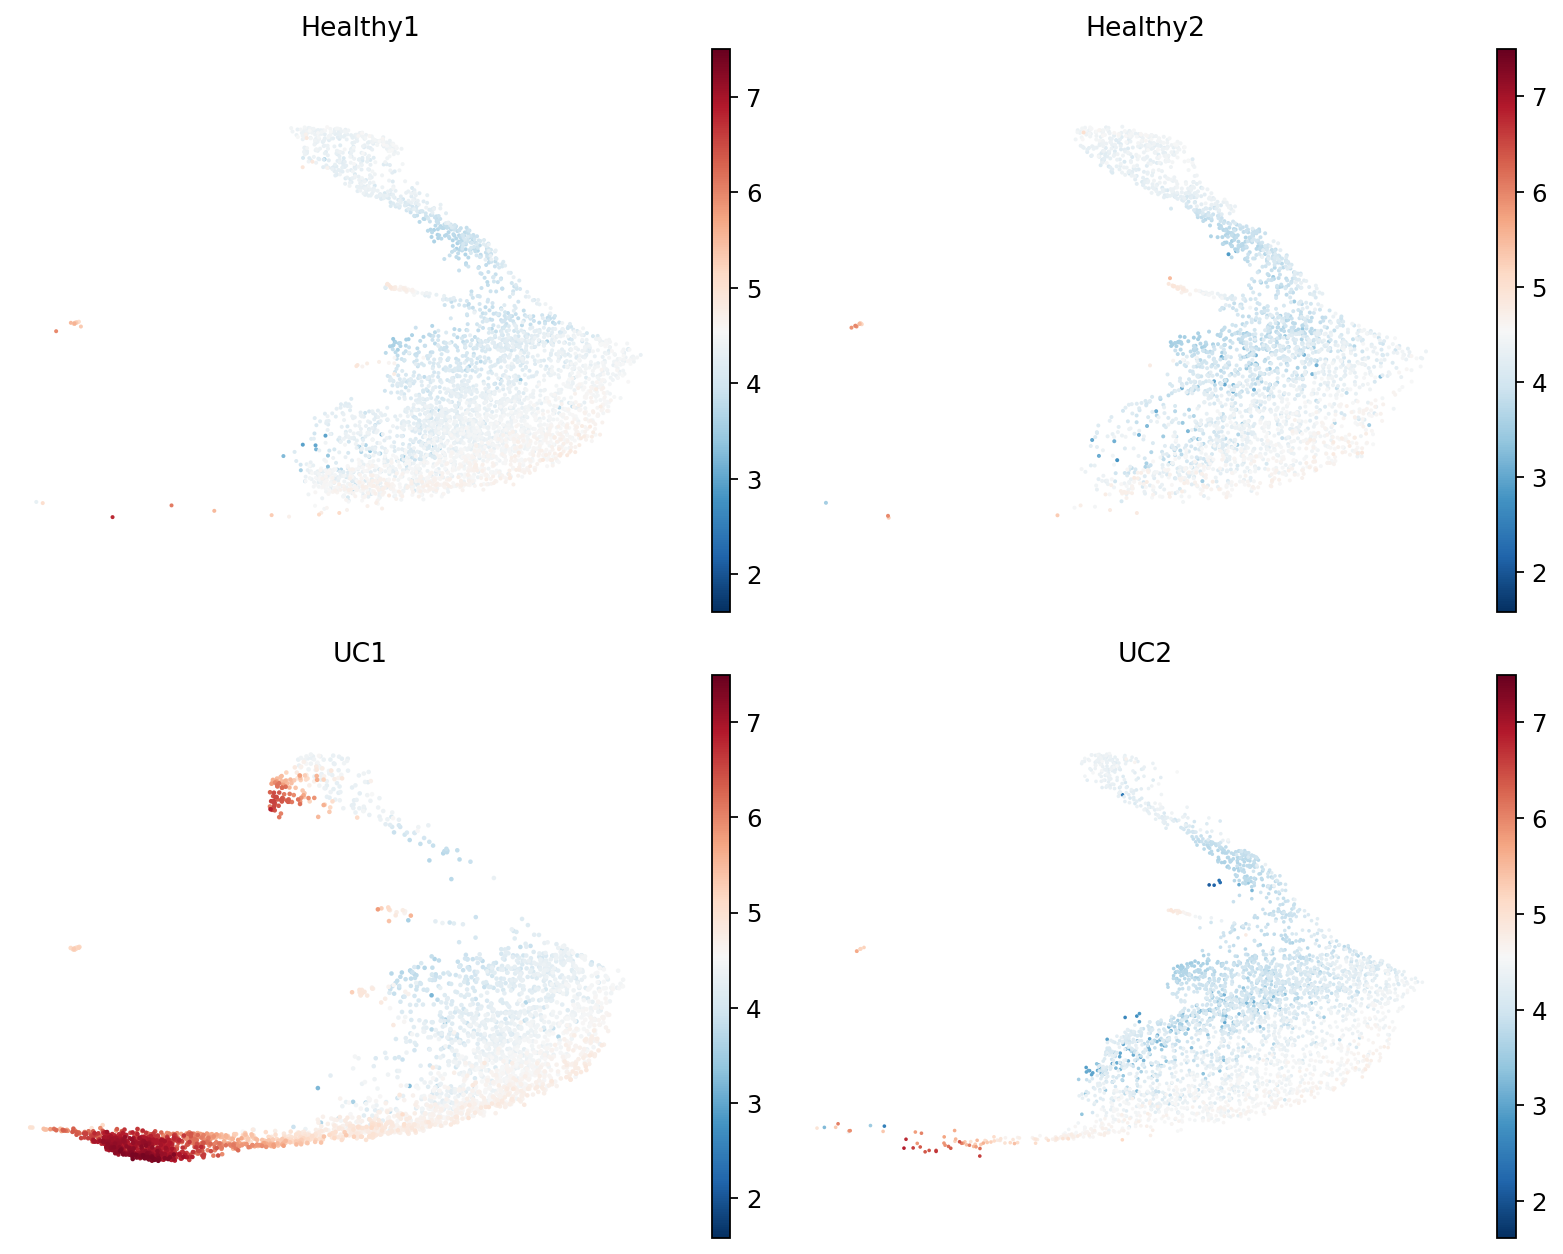

In [9]:
# Figure A
split_umap(adata, split_by = "sample.condition",layer="MAGIC_imputed_data",
    color=["CTNNB1"], vmax = 7.5,save =False, frameon=False)

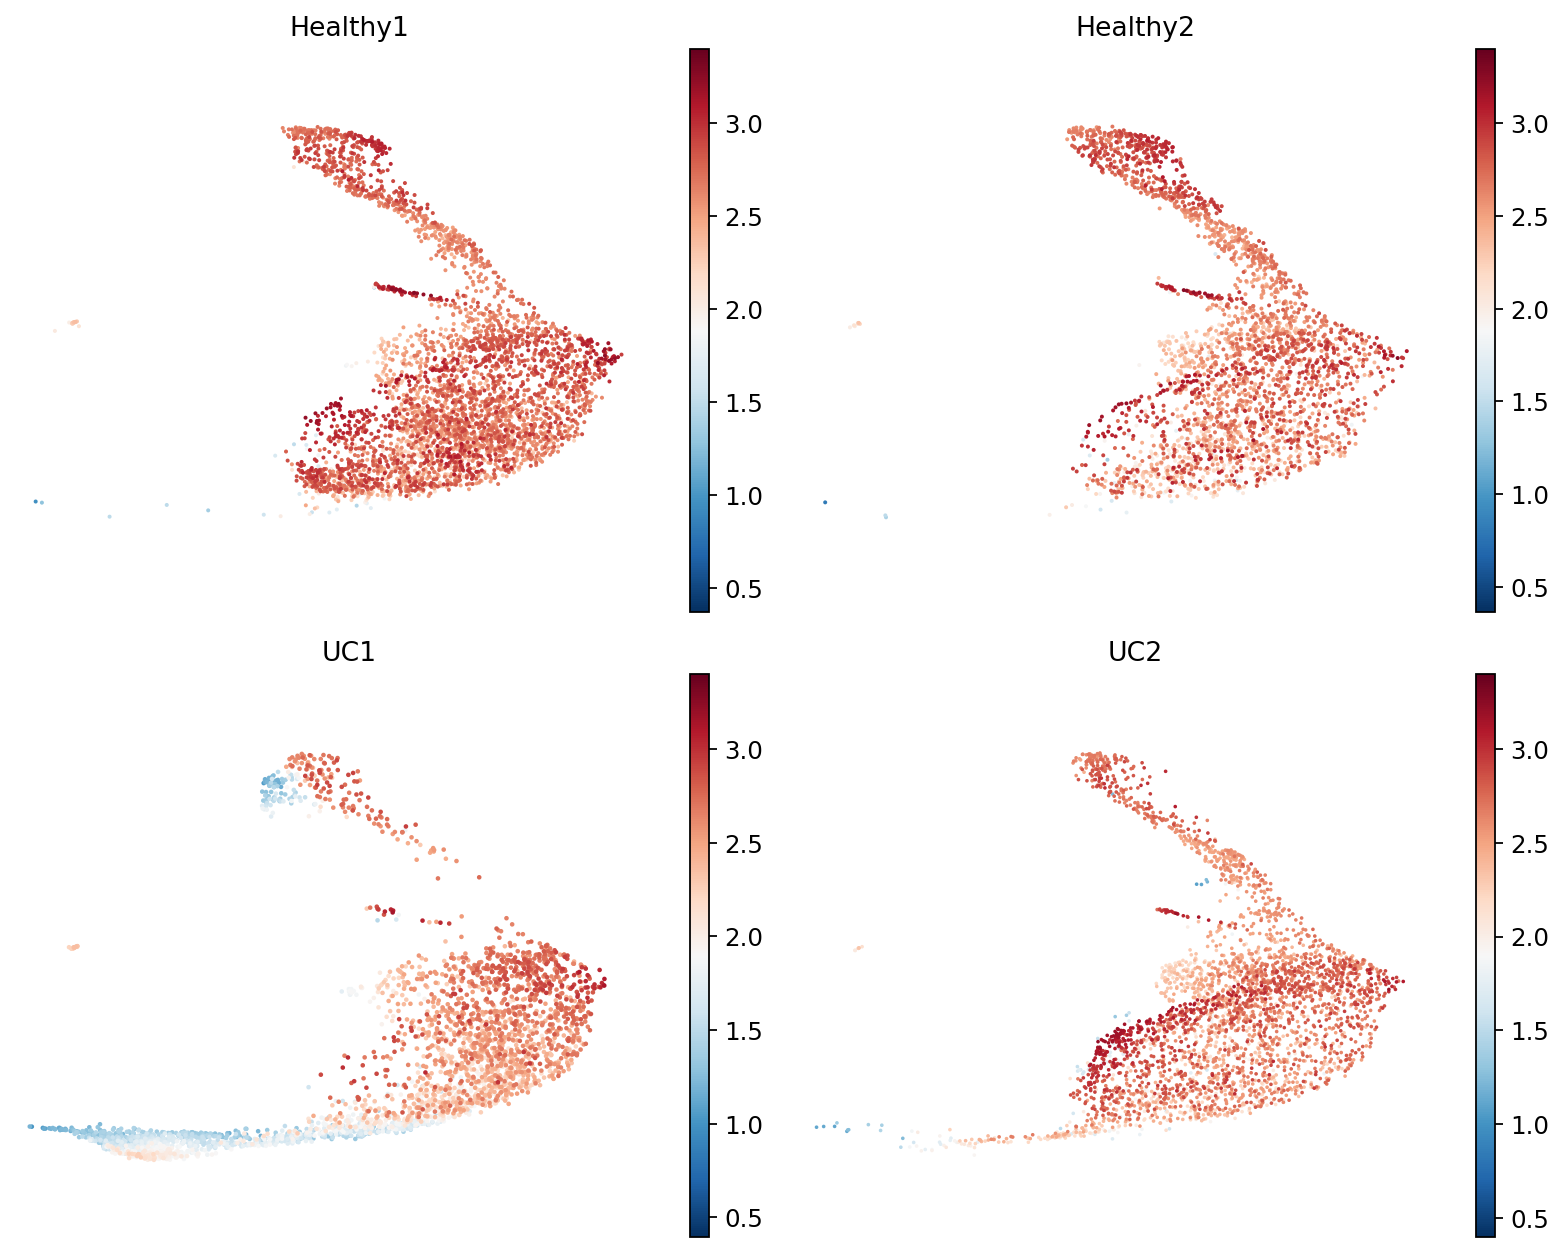

In [10]:
# Figure B
# APC plot on 3D Section (Figure 4)
split_umap(adata, split_by = "sample.condition",layer="MAGIC_imputed_data",
    color=["APC"], vmax = 3.4, save =False, frameon=False)

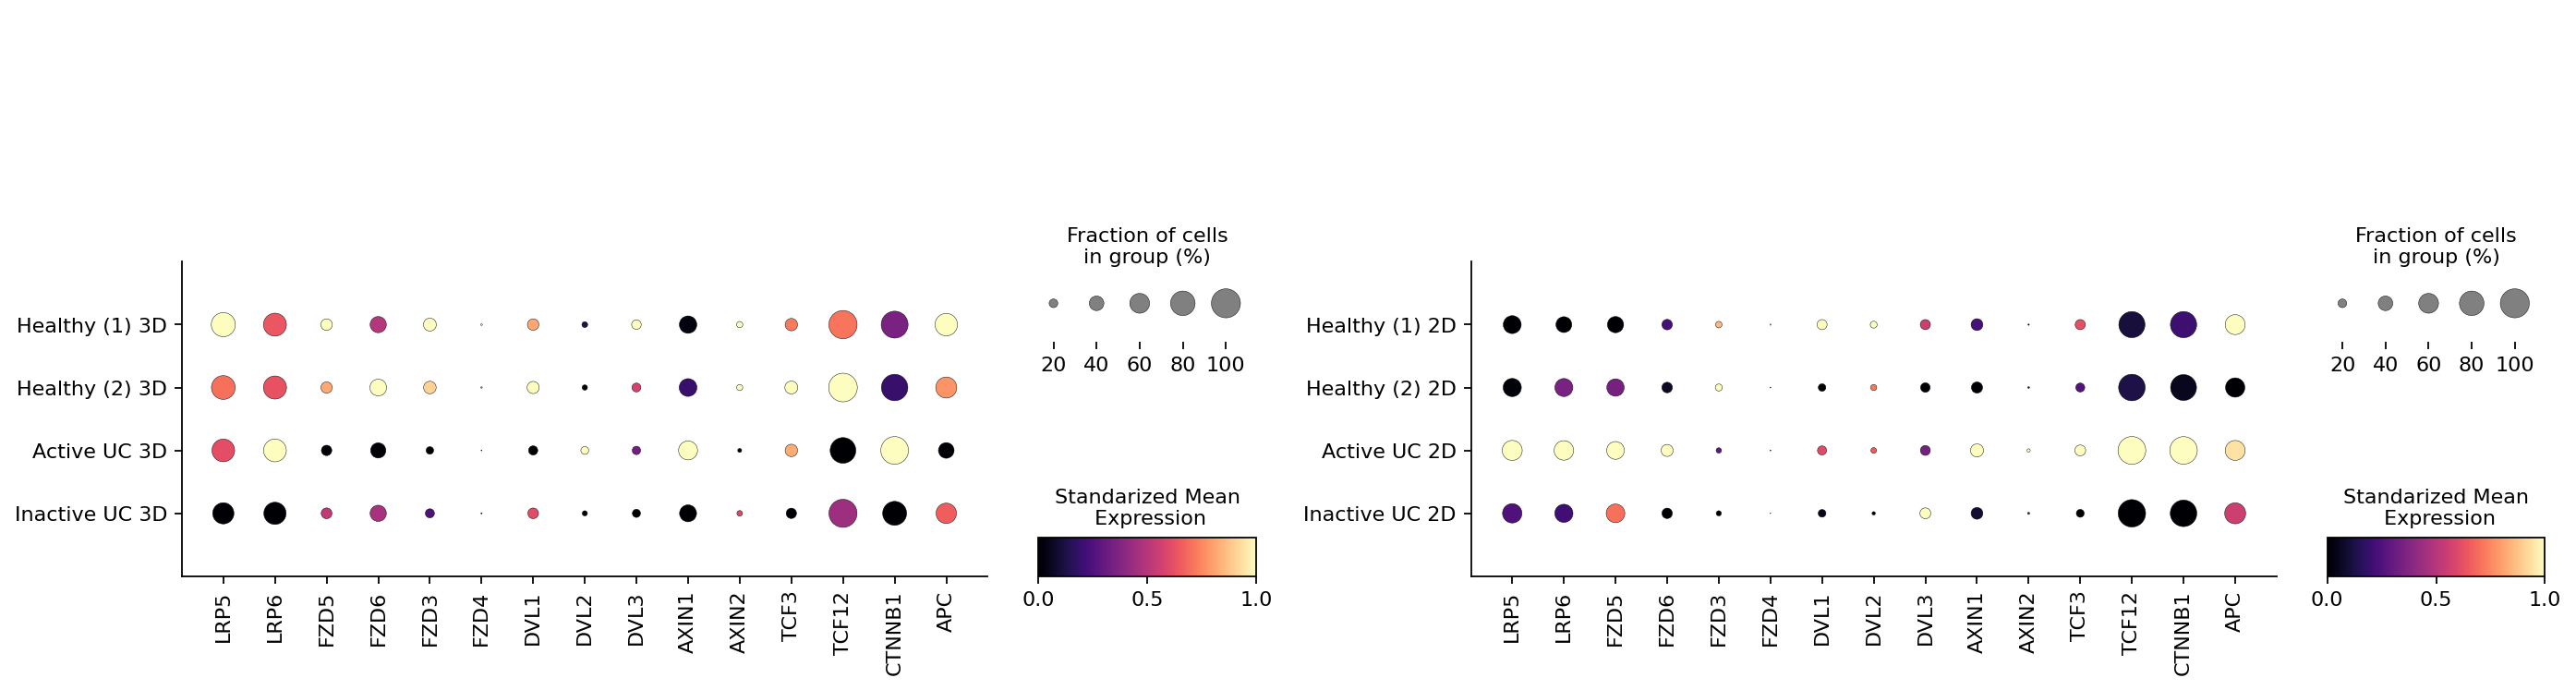

In [11]:
#Figure 4C
fig, axs = plt.subplots(1, 2, figsize=(20.5, 5))
sc.pl.dotplot(adata_3d, ["LRP5","LRP6", "FZD5", "FZD6","FZD3", "FZD4", 
                      "DVL1", "DVL2", "DVL3", "AXIN1", "AXIN2","TCF3", "TCF12", 
                      "CTNNB1","APC"],
              groupby = ['new.orig.ident'], standard_scale="var", 
              cmap="magma",
              colorbar_title = "Standarized Mean\n Expression",
              ax=axs[0],show=False)


sc.pl.dotplot(adata_2d, ["LRP5","LRP6", "FZD5", "FZD6","FZD3", "FZD4", 
                      "DVL1", "DVL2", "DVL3", "AXIN1", "AXIN2","TCF3", "TCF12", 
                      "CTNNB1","APC"],
              cmap="magma",
              groupby = ['new.orig.ident'], standard_scale="var", 
              colorbar_title = "Standarized Mean\n Expression",
              ax=axs[1])

#fig.savefig('Dotplot_Figure4C.png', transparent = False, dpi = 600)

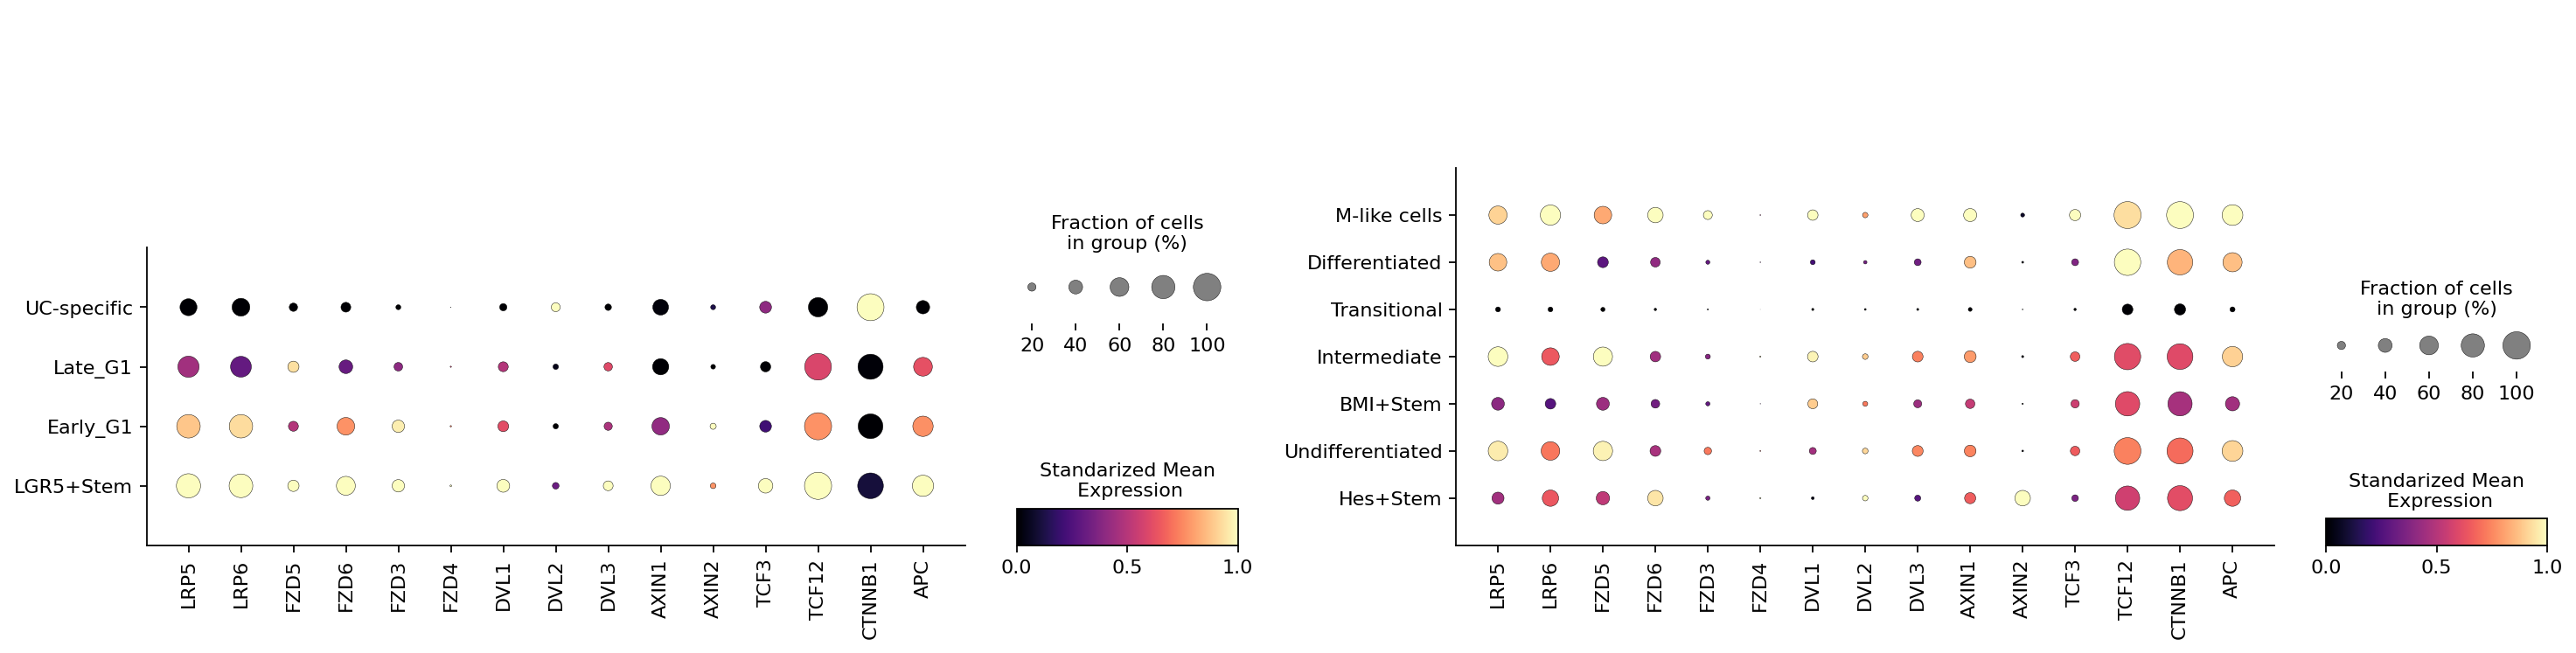

In [15]:
#Figure 4D
only_3d = adata[adata.obs['cell_anno'].isin(["LGR5+Stem_3D","Early_G1_3D","Late_G1_3D","UC-specific_3D"])]


new_names2 = ['Late_G1','Early_G1','LGR5+Stem','UC-specific']
only_3d.rename_categories('cell_anno', new_names2)

only_2d = adata[adata.obs['cell_anno'].isin(["BMI+Stem_2D","Undifferentiated_2D","Hes+Stem_2D","Transitional_2D",
                                                'Intermediate_2D','Differentiated_2D','M-like_2D'])]
new_names2 = ['Undifferentiated','Intermediate','Differentiated','BMI+Stem','Transitional','M-like cells','Hes+Stem']
only_2d.rename_categories('cell_anno', new_names2)

fig, axs = plt.subplots(1, 2, figsize=(22, 5))
sc.pl.dotplot(only_3d, ["LRP5","LRP6", "FZD5", "FZD6","FZD3", "FZD4", 
                      "DVL1", "DVL2", "DVL3", "AXIN1", "AXIN2","TCF3", "TCF12", 
                      "CTNNB1","APC"], categories_order = ["UC-specific","Late_G1","Early_G1","LGR5+Stem"],
              cmap = "magma",
              groupby = ['cell_anno'], standard_scale="var", colorbar_title = "Standarized Mean\n Expression", 
              ax=axs[0],show=False)


sc.pl.dotplot(only_2d, ["LRP5","LRP6", "FZD5", "FZD6","FZD3", "FZD4", 
                      "DVL1", "DVL2", "DVL3", "AXIN1", "AXIN2","TCF3", "TCF12", 
                      "CTNNB1","APC"],
              categories_order = ['M-like cells','Differentiated',"Transitional",'Intermediate',
                                  "BMI+Stem","Undifferentiated","Hes+Stem"],
              cmap = "magma",
              groupby = ['cell_anno'], standard_scale="var", colorbar_title = "Standarized Mean\n Expression",
              ax=axs[1])

#fig.savefig('DotPlot_Figure_4D.png', transparent = False, dpi = 600)

# Figure 5

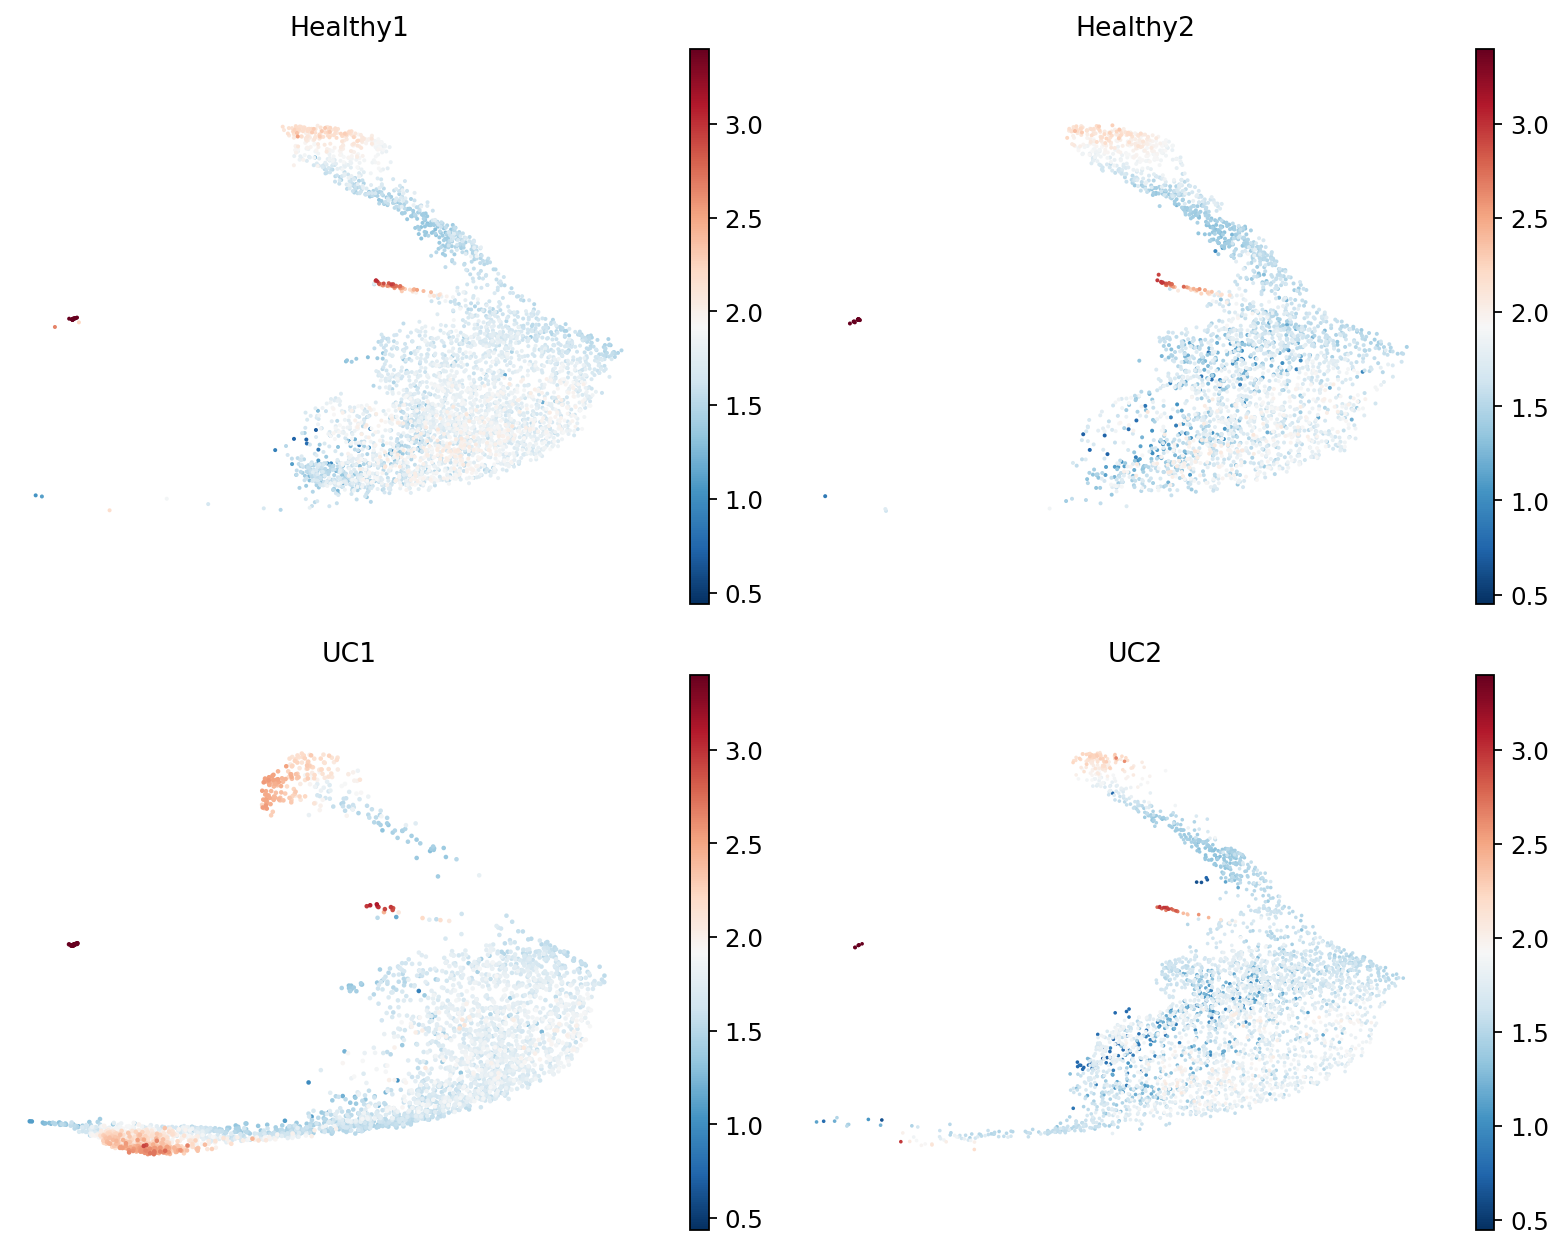

In [16]:
# HES1 plot on 3D Section
split_umap(adata, split_by = "sample.condition",layer="MAGIC_imputed_data",
    color=["HES1"], vmax = 3.4, save =False, frameon=False)

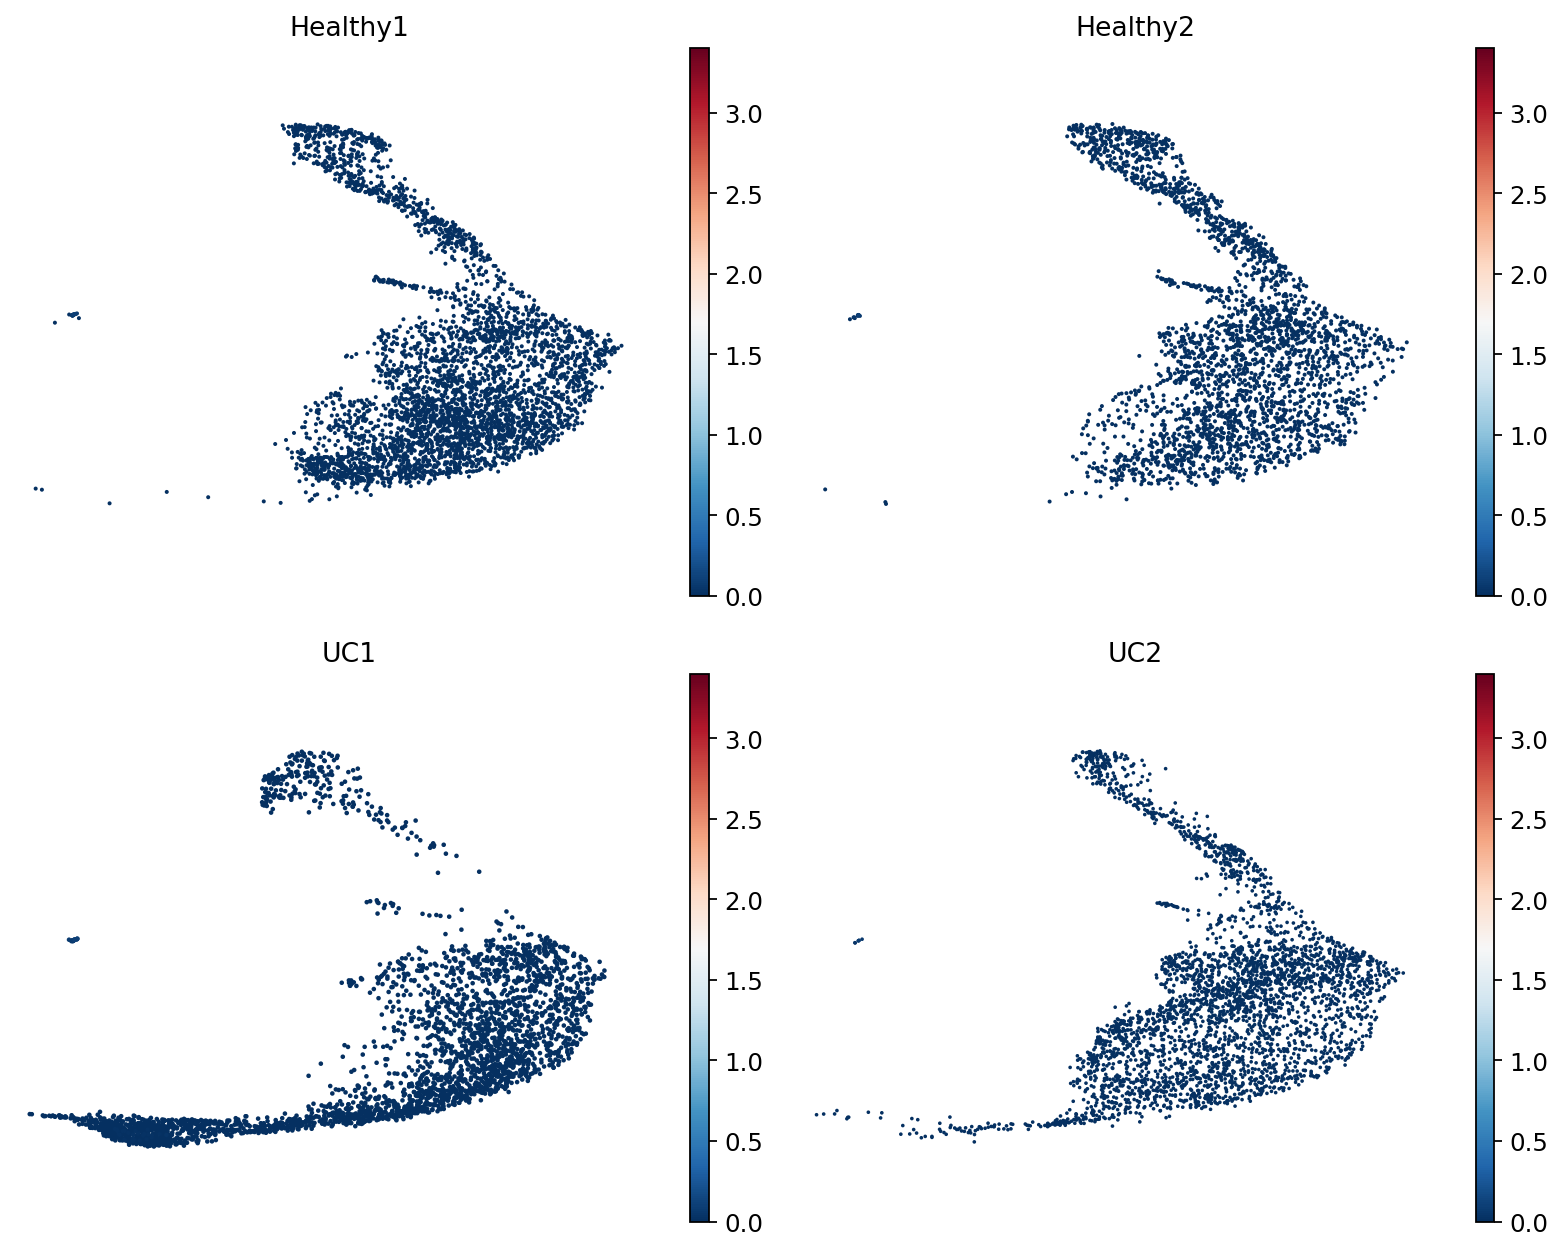

In [17]:
# ATOH1 plot on 3D Section (Figure 5)
split_umap(adata, split_by = "sample.condition",layer="MAGIC_imputed_data",
    color=["ATOH1"], vmax = 3.4, save =False, frameon=False)

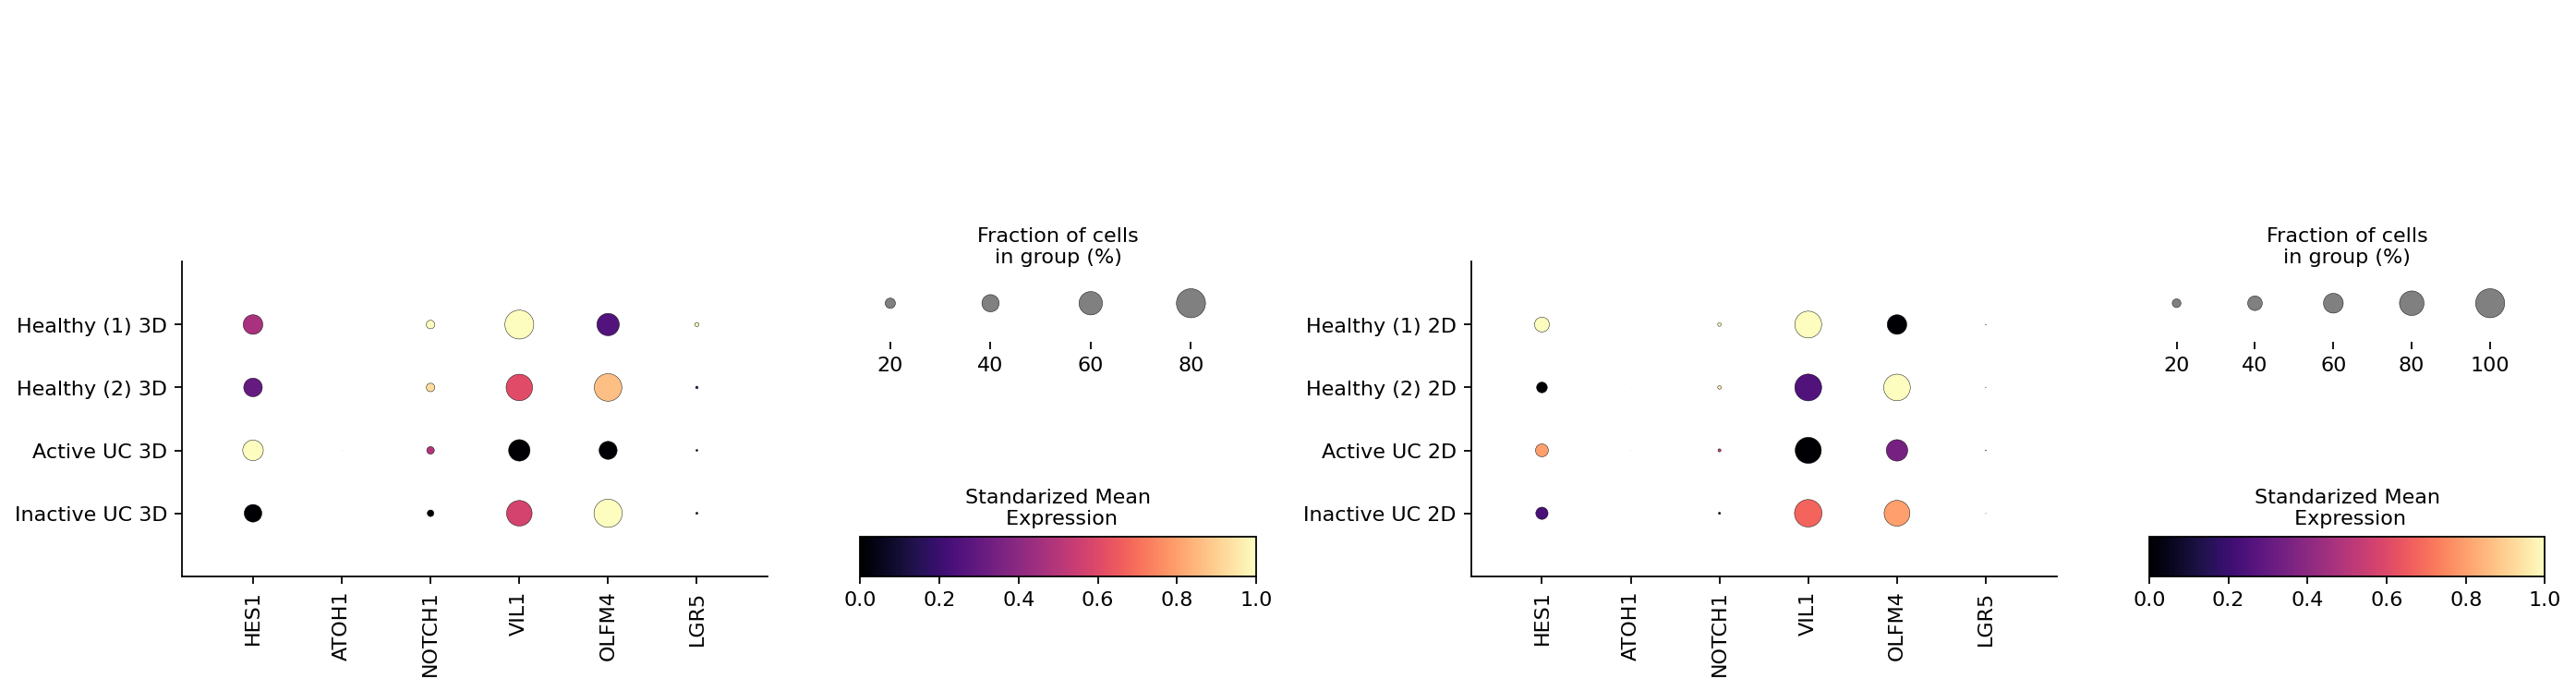

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(20.5, 5))
sc.pl.dotplot(adata_3d, ['HES1','ATOH1', 'NOTCH1','VIL1','OLFM4','LGR5'],
              groupby = ['new.orig.ident'], standard_scale="var", 
              colorbar_title = "Standarized Mean\n Expression",
              cmap = "magma",
              ax=axs[0],show=False)


sc.pl.dotplot(adata_2d, ['HES1','ATOH1', 'NOTCH1','VIL1','OLFM4','LGR5'],
              groupby = ['new.orig.ident'], standard_scale="var", 
              colorbar_title = "Standarized Mean\n Expression",
              cmap = "magma",
              ax=axs[1])

#fig.savefig('Dotplot_Figure5E.png', transparent = False, dpi = 600)

# Supplementary Figure 1

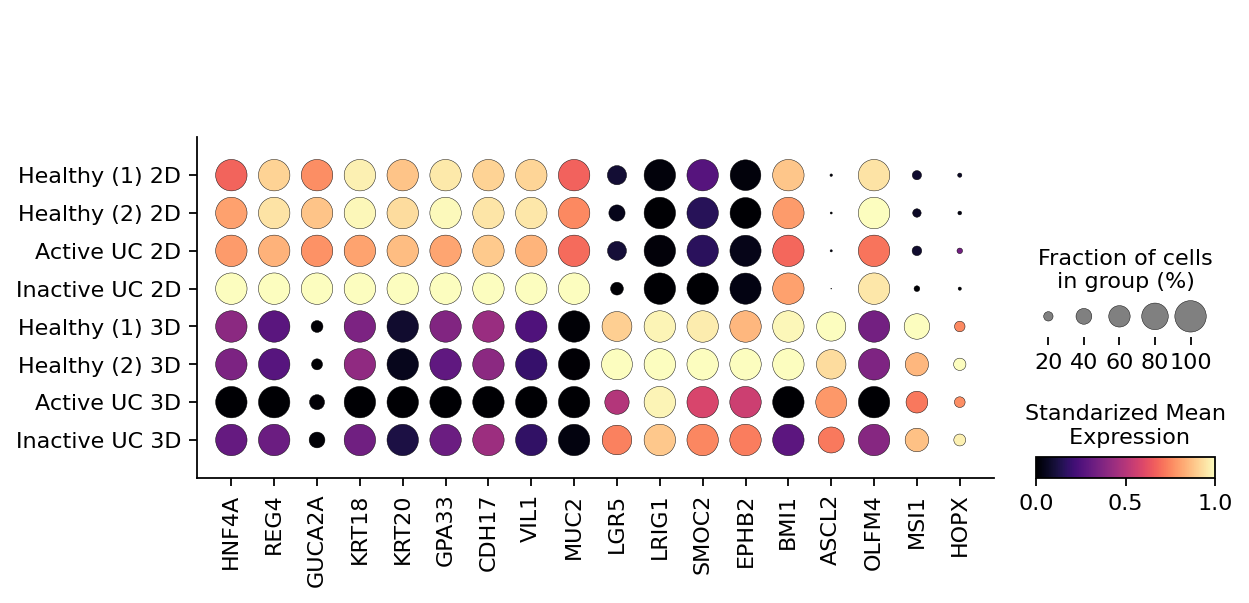

In [19]:
sc.pl.dotplot(adata, ['HNF4A','REG4','GUCA2A','KRT18','KRT20','GPA33','CDH17',"VIL1","MUC2",
                       'LGR5','LRIG1','SMOC2','EPHB2','BMI1','ASCL2','OLFM4','MSI1','HOPX'],
              groupby = ['new.orig.ident'], 
              layer="MAGIC_imputed_data",
              categories_order =['Healthy (1) 2D','Healthy (2) 2D','Active UC 2D','Inactive UC 2D',
                                 'Healthy (1) 3D','Healthy (2) 3D','Active UC 3D','Inactive UC 3D'],
              standard_scale="var", 
              cmap = "magma",
              colorbar_title = "Standarized Mean\n Expression", 
              #save = "Suppementary_Figure_1_Magma.png"
             )

# Supplementary Figure 8

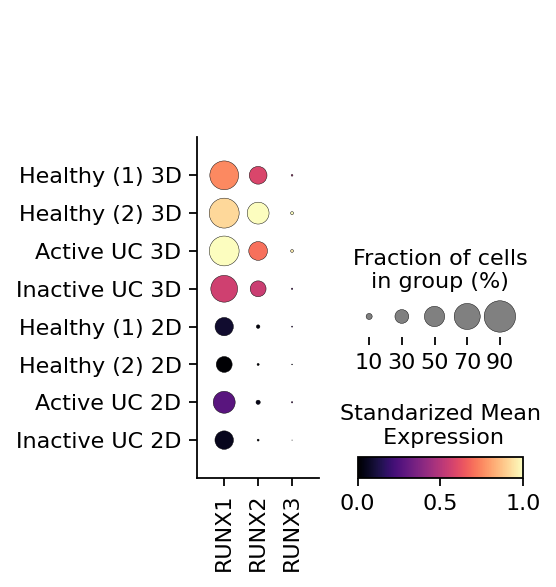

In [20]:
sc.pl.dotplot(adata, ['RUNX1','RUNX2','RUNX3'],
              groupby = ['new.orig.ident'], 
              categories_order =['Healthy (1) 3D','Healthy (2) 3D','Active UC 3D','Inactive UC 3D',
                                'Healthy (1) 2D','Healthy (2) 2D','Active UC 2D','Inactive UC 2D'],
              standard_scale="var", 
              colorbar_title = "Standarized Mean\n Expression", 
              cmap = "magma",
              #save = "Suppementary_Figure_8_Magma.png"
             )